# **Import**

In [2]:
import warnings

warnings.filterwarnings('ignore')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# **Data Load**

In [3]:
cd /content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data

/content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data


In [4]:
train_a = pd.read_csv('train_a_derived.csv')
train_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647237 entries, 0 to 647236
Data columns (total 47 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Label                      647237 non-null  int64  
 1   Age                        647237 non-null  int64  
 2   A1_response_rate           647237 non-null  float64
 3   A1_left_response_rate      647237 non-null  float64
 4   A1_right_response_rate     647237 non-null  float64
 5   A1_fast_response_rate      647237 non-null  float64
 6   A1_mean_response_time      647237 non-null  float64
 7   A1_fast_avg_rt             647237 non-null  float64
 8   A1_direction_diff_rt       647237 non-null  float64
 9   A2_response_rate           647237 non-null  float64
 10  A2_slow_to_fast_rt_diff    647237 non-null  float64
 11  A2_correct_ratio_by_speed  647237 non-null  float64
 12  A2_mean_response_time      647237 non-null  float64
 13  A3_valid_accuracy          64

# **Clustering**

In [17]:
results = []
y = train_a['Label']

def compute_clusters_silhouette(df, feature, target, sample_size=10000, random_state=42):
    """
    feature별 클러스터링 + silhouette 계산
    Returns: labels, silhouette_score, x_scaled, x_sample
    """
    # feature 데이터
    x_col = df[[feature]].dropna()
    idx = x_col.index
    y_col = target.loc[idx]

    # 샘플링: Stratified
    if len(x_col) > sample_size:
        x_sample, _, y_sample, _ = train_test_split(
            x_col, y_col,
            train_size=sample_size,
            stratify=y_col,
            random_state=random_state
        )
    else:
        x_sample = x_col
        y_sample = y_col

    # 정규화
    x_scaled = StandardScaler().fit_transform(x_sample)

    # KMeans(k=2)
    kmeans = KMeans(n_clusters=2, n_init=5, max_iter=200, random_state=random_state)
    labels = kmeans.fit_predict(x_scaled)

    # Silhouette 계산 (cluster가 1개면 NaN 처리)
    if len(np.unique(labels)) < 2:
        sil_score = np.nan
        print(f"Feature: {feature}, cluster가 1개라 silhouette 계산 불가")
    else:
        sil_score = silhouette_score(x_scaled, labels)
        print(f"Feature: {feature}, Silhouette Score: {sil_score:.4f}")

    return labels, sil_score, x_scaled, x_sample

def plot_cluster_target_mean(labels, x_sample, target, feature_name):
    """
    Cluster별 target 평균 계산 + bar plot 시각화
    Args:
        labels: KMeans 클러스터 레이블 (1차원 array)
        x_sample: 클러스터링에 사용한 feature 샘플 (DataFrame)
        target: target Series (0/1)
        feature_name: feature 이름 (str)
    """
    # target과 합치기
    tmp = pd.DataFrame({
        feature_name: x_sample.values.flatten(),
        'Cluster': labels,
        'Target': target.loc[x_sample.index].values
    })

    # 클러스터별 target 평균 계산
    cluster_mean = tmp.groupby('Cluster')['Target'].mean()
    diff = cluster_mean.max() - cluster_mean.min()

    # 위험 확률이 높은 cluster가 항상 오른쪽으로 오도록 정렬
    cluster_mean = cluster_mean.sort_values(ascending=True)

    print("Cluster별 Target 평균:")
    print(cluster_mean)
    print(f"Target 평균 차이 (Cluster Max - Min): {diff:.4f}")

    # bar plot
    plt.figure(figsize=(6, 4))
    sns.barplot(x=cluster_mean.index, y=cluster_mean.values, palette='tab10')
    plt.title(f"{feature_name} - Mean Target by Cluster (diff={diff:.3f})")
    plt.xlabel("Cluster")
    plt.ylabel("Mean Target (Risk Probability)")
    plt.show()

    return diff

## **Age**

Feature: Age, Silhouette Score: 0.6683
Cluster별 Target 평균:
Cluster
0    0.014216
1    0.033311
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0191


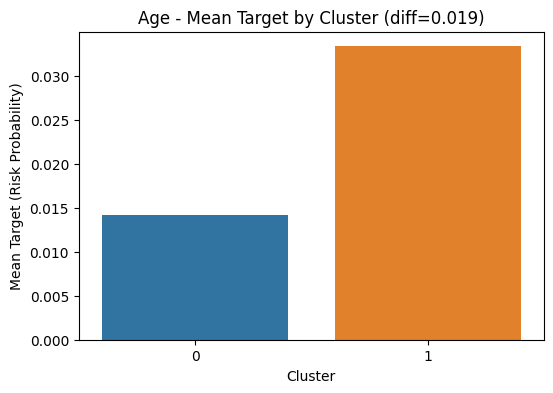

In [18]:
col = 'Age'

labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(
    train_a, col, y
    )

diff = plot_cluster_target_mean(labels, x_sample, y, col)

results.append({
    'Feature': col,
    'Silhouette': sil_score,
    'Cluster Diff': diff
})

## **A1**

Feature: A1_response_rate, Silhouette Score: 0.9640
Cluster별 Target 평균:
Cluster
1    0.000000
0    0.022934
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0229


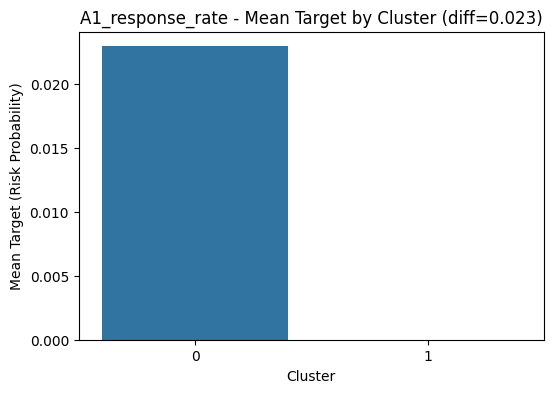

Feature: A1_left_response_rate, Silhouette Score: 0.9666
Cluster별 Target 평균:
Cluster
1    0.000000
0    0.022983
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0230


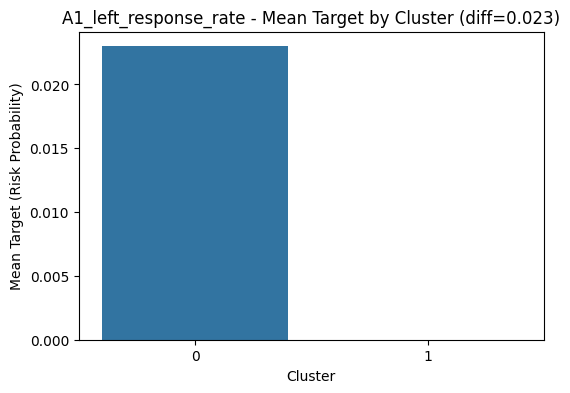

Feature: A1_right_response_rate, Silhouette Score: 0.9634
Cluster별 Target 평균:
Cluster
1    0.00000
0    0.02298
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0230


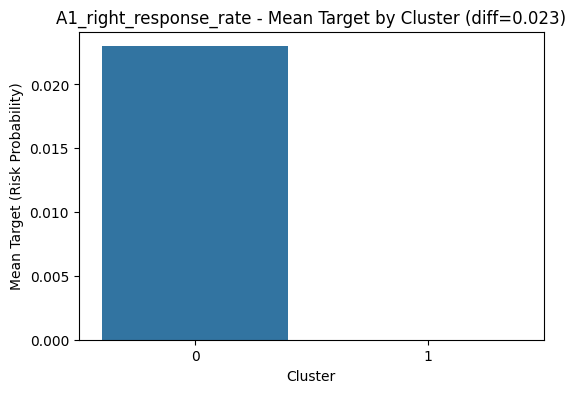

Feature: A1_fast_response_rate, Silhouette Score: 0.9604
Cluster별 Target 평균:
Cluster
1    0.005556
0    0.023014
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0175


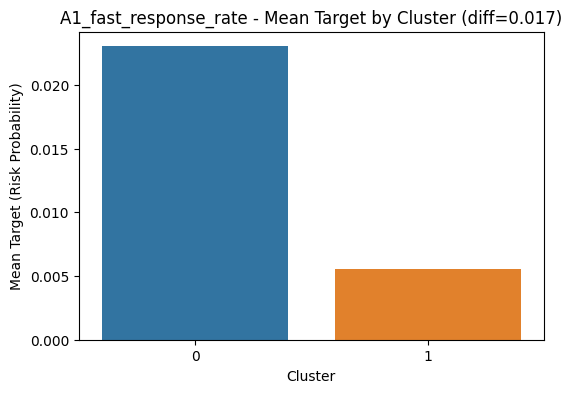

Feature: A1_mean_response_time, Silhouette Score: 0.9794
Cluster별 Target 평균:
Cluster
0    0.022304
1    0.039823
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0175


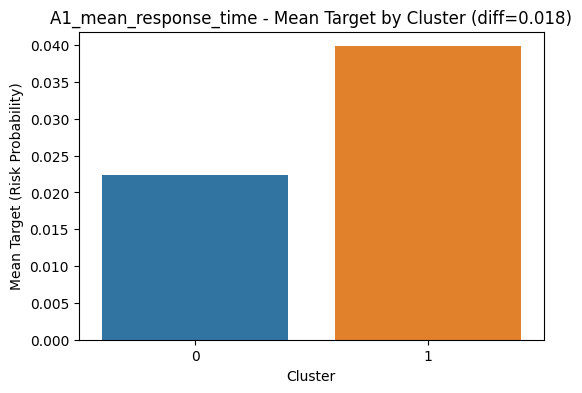

Feature: A1_fast_avg_rt, Silhouette Score: 0.9867
Cluster별 Target 평균:
Cluster
0    0.022508
1    0.036496
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0140


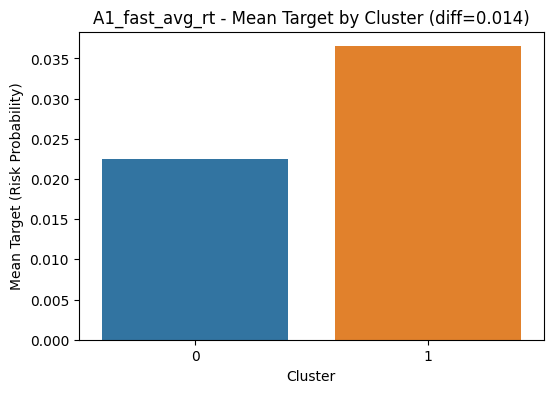

Feature: A1_direction_diff_rt, Silhouette Score: 0.9969
Cluster별 Target 평균:
Cluster
1    0.006645
0    0.023198
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0166


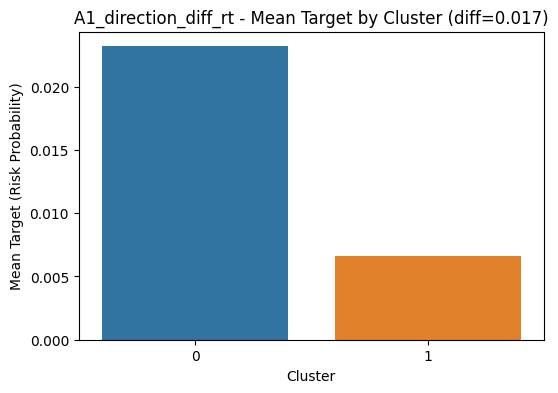

In [19]:
feature_list = ['A1_response_rate', 'A1_left_response_rate', 'A1_right_response_rate',
                'A1_fast_response_rate', 'A1_mean_response_time',
                'A1_fast_avg_rt', 'A1_direction_diff_rt']
results_a1 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_a, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_a1.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [35]:
results_a1_df = pd.DataFrame(results_a1).sort_values('Cluster Diff', ascending=False)
results_a1_df

,Feature,Silhouette,Cluster Diff
1,A1_left_response_rate,0.966562,0.022983
2,A1_right_response_rate,0.963386,0.022980
0,A1_response_rate,0.964039,0.022934
4,A1_mean_response_time,0.979427,0.017519
3,A1_fast_response_rate,0.960357,0.017459
6,A1_direction_diff_rt,0.996880,0.016554
5,A1_fast_avg_rt,0.986719,0.013988


## **A2**

Feature: A2_response_rate, Silhouette Score: 0.9564
Cluster별 Target 평균:
Cluster
0    0.022536
1    0.024194
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0017


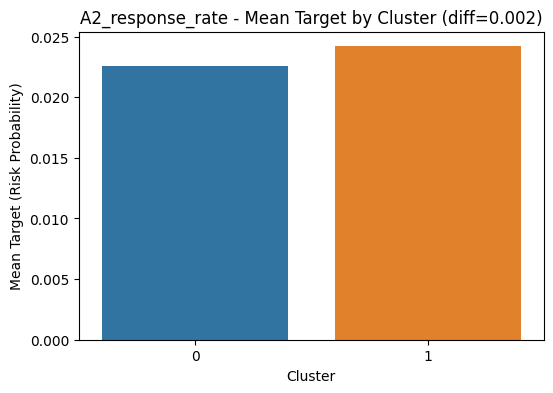

Feature: A2_slow_to_fast_rt_diff, Silhouette Score: 0.9919
Cluster별 Target 평균:
Cluster
0    0.022659
1    0.038462
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0158


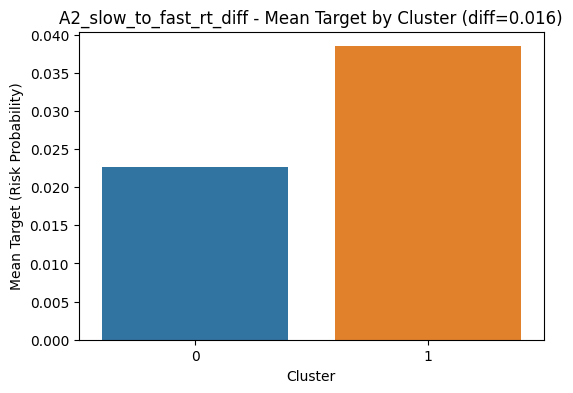

Feature: A2_correct_ratio_by_speed, Silhouette Score: 0.9971
Cluster별 Target 평균:
Cluster
1    0.016166
0    0.022996
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0068


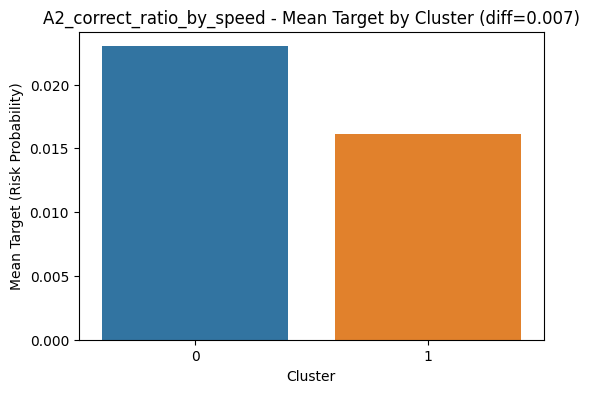

Feature: A2_mean_response_time, Silhouette Score: 0.9940
Cluster별 Target 평균:
Cluster
0    0.022250
1    0.035608
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0134


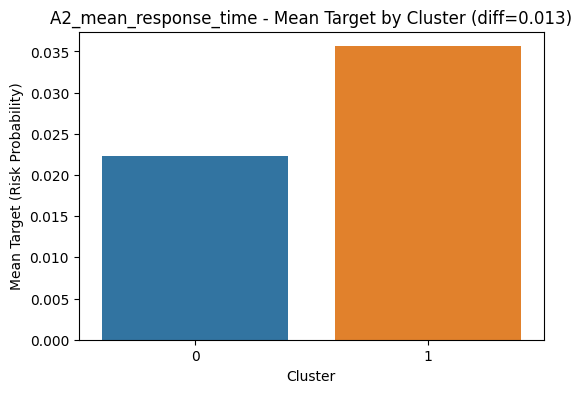

In [21]:
feature_list = ['A2_response_rate', 'A2_slow_to_fast_rt_diff',
                'A2_correct_ratio_by_speed', 'A2_mean_response_time']
results_a2 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_a, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_a2.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [36]:
results_a2_df = pd.DataFrame(results_a2).sort_values('Cluster Diff', ascending=False)
results_a2_df

,Feature,Silhouette,Cluster Diff
1,A2_slow_to_fast_rt_diff,0.991868,0.015803
3,A2_mean_response_time,0.994035,0.013358
2,A2_correct_ratio_by_speed,0.997109,0.006829
0,A2_response_rate,0.956370,0.001658


## **A3**

Feature: A3_valid_accuracy, cluster가 1개라 silhouette 계산 불가
Cluster별 Target 평균:
Cluster
0    0.0227
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0000


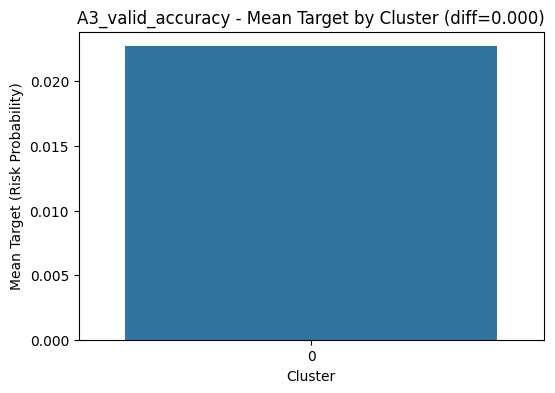

Feature: A3_invalid_accuracy, cluster가 1개라 silhouette 계산 불가
Cluster별 Target 평균:
Cluster
0    0.0227
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0000


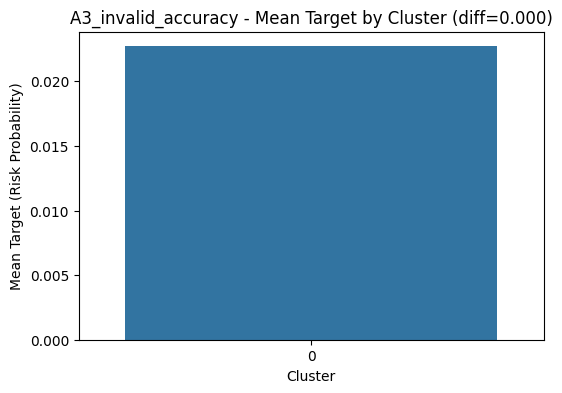

Feature: A3_total_accuracy, Silhouette Score: 0.8967
Cluster별 Target 평균:
Cluster
0    0.021961
1    0.034843
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0129


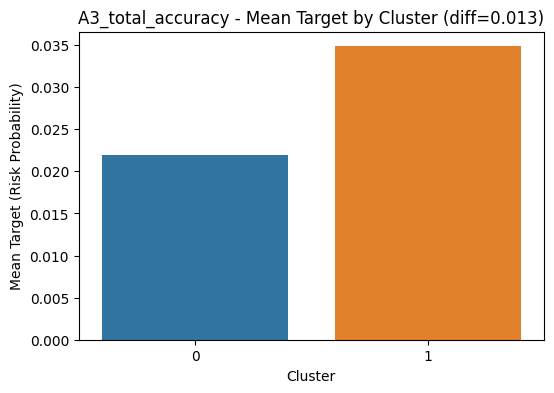

Feature: A3_valid_rt, Silhouette Score: 0.6772
Cluster별 Target 평균:
Cluster
0    0.018953
1    0.031978
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0130


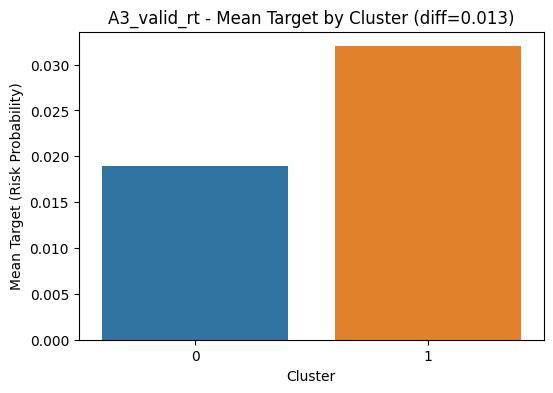

Feature: A3_invalid_rt, Silhouette Score: 0.5883
Cluster별 Target 평균:
Cluster
0    0.019453
1    0.028042
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0086


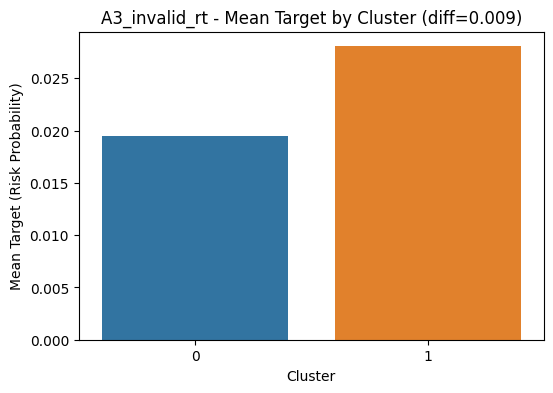

Feature: A3_correct_rt, Silhouette Score: 0.9981
Cluster별 Target 평균:
Cluster
0    0.019549
1    0.039106
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0196


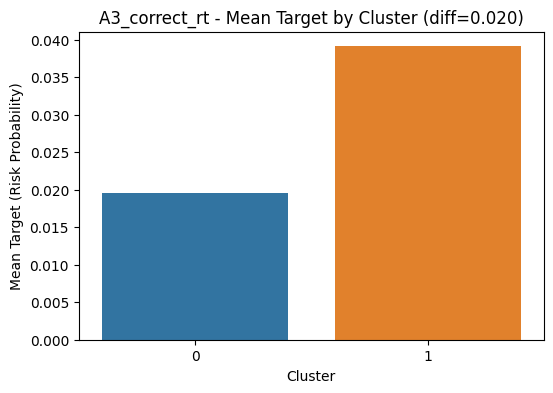

Feature: A3_incorrect_rt, Silhouette Score: 0.6500
Cluster별 Target 평균:
Cluster
0    0.018754
1    0.031841
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0131


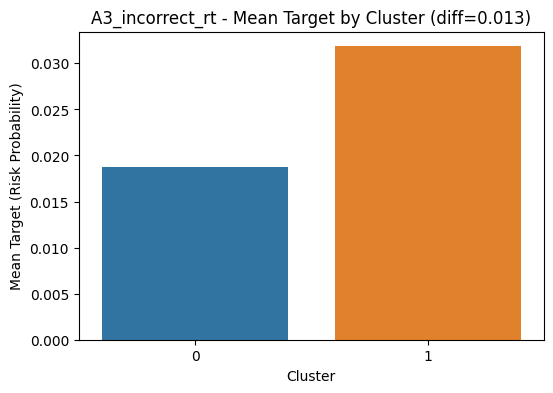

Feature: A3_accuracy_gap, cluster가 1개라 silhouette 계산 불가
Cluster별 Target 평균:
Cluster
0    0.0227
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0000


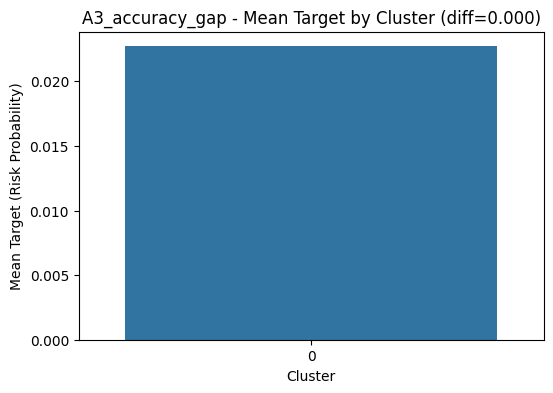

In [23]:
feature_list = ['A3_valid_accuracy', 'A3_invalid_accuracy', 'A3_total_accuracy',
                'A3_valid_rt', 'A3_invalid_rt', 'A3_correct_rt',
                'A3_incorrect_rt', 'A3_accuracy_gap']
results_a3 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_a, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_a3.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [37]:
results_a3_df = pd.DataFrame(results_a3).sort_values('Cluster Diff', ascending=False)
results_a3_df

,Feature,Silhouette,Cluster Diff
5,A3_correct_rt,0.998061,0.019557
6,A3_incorrect_rt,0.649968,0.013086
3,A3_valid_rt,0.677205,0.013025
2,A3_total_accuracy,0.896676,0.012883
4,A3_invalid_rt,0.588331,0.008589
1,A3_invalid_accuracy,NaN,0.000000
0,A3_valid_accuracy,NaN,0.000000
7,A3_accuracy_gap,NaN,0.000000


## **A4**

Feature: A4_congruent_accuracy, Silhouette Score: 0.8821
Cluster별 Target 평균:
Cluster
1    0.022085
0    0.024354
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0023


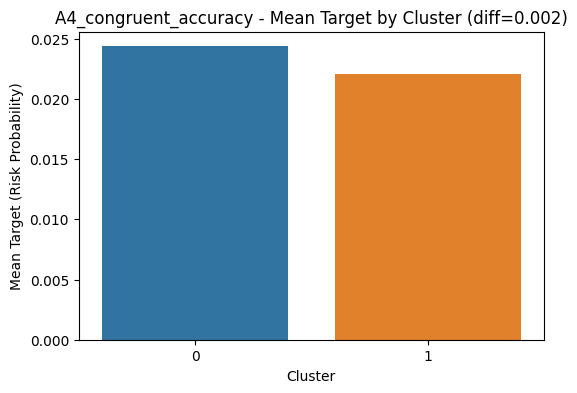

Feature: A4_incongruent_accuracy, Silhouette Score: 0.7582
Cluster별 Target 평균:
Cluster
0    0.021818
1    0.026995
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0052


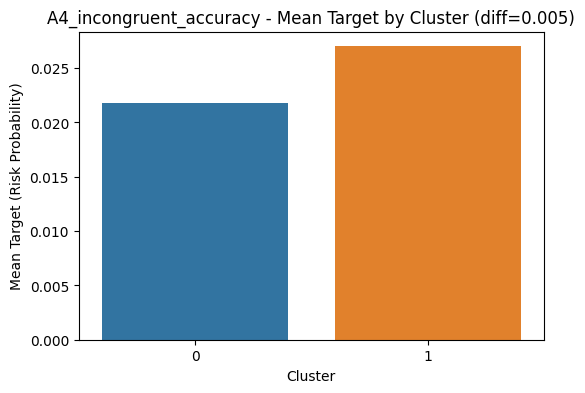

Feature: A4_accuracy_gap, Silhouette Score: 0.6841
Cluster별 Target 평균:
Cluster
0    0.022416
1    0.024596
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0022


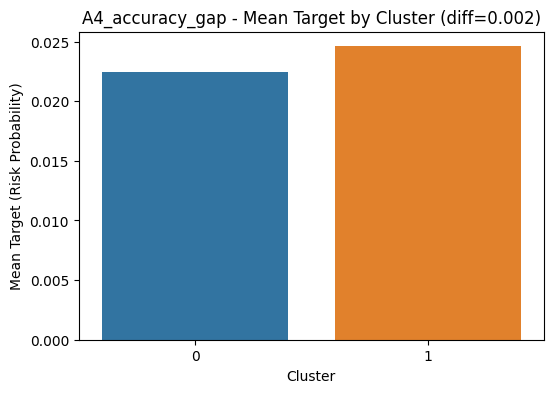

Feature: A4_mean_rt_con, Silhouette Score: 0.6041
Cluster별 Target 평균:
Cluster
0    0.020707
1    0.027149
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0064


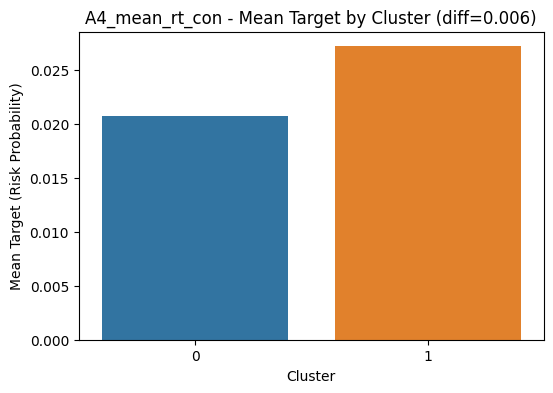

Feature: A4_mean_rt_incon, Silhouette Score: 0.5898
Cluster별 Target 평균:
Cluster
0    0.020637
1    0.026864
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0062


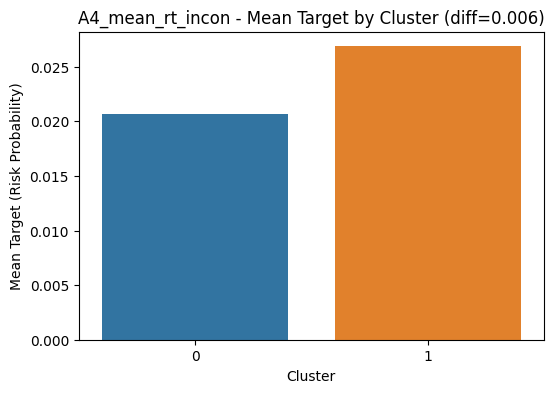

Feature: A4_rt_gap, Silhouette Score: 0.5584
Cluster별 Target 평균:
Cluster
0    0.022495
1    0.022939
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0004


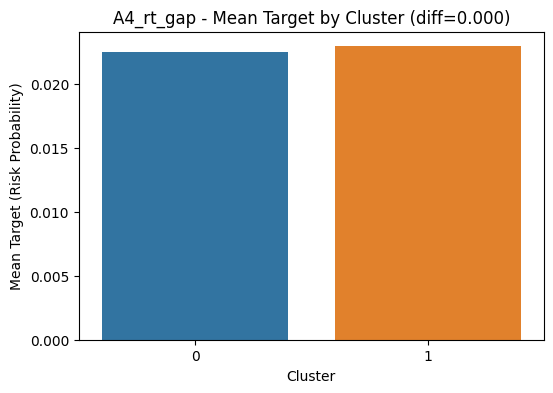

Feature: A4_response_rate, cluster가 1개라 silhouette 계산 불가
Cluster별 Target 평균:
Cluster
0    0.0227
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0000


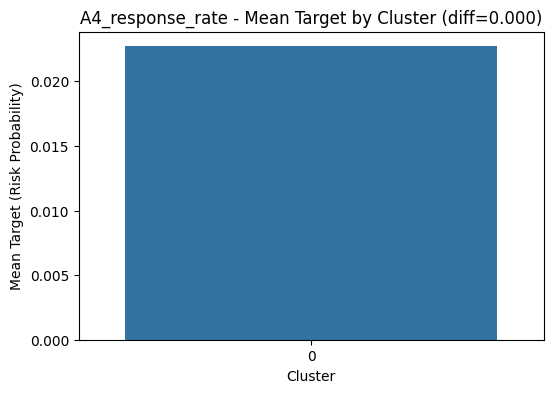

In [25]:
feature_list = ['A4_congruent_accuracy', 'A4_incongruent_accuracy',
                'A4_accuracy_gap', 'A4_mean_rt_con', 'A4_mean_rt_incon',
                'A4_rt_gap', 'A4_response_rate']
results_a4 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_a, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_a4.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [38]:
results_a4_df = pd.DataFrame(results_a4).sort_values('Cluster Diff', ascending=False)
results_a4_df

,Feature,Silhouette,Cluster Diff
3,A4_mean_rt_con,0.604092,0.006443
4,A4_mean_rt_incon,0.589806,0.006227
1,A4_incongruent_accuracy,0.758192,0.005178
0,A4_congruent_accuracy,0.882101,0.002269
2,A4_accuracy_gap,0.684131,0.002180
5,A4_rt_gap,0.558365,0.000444
6,A4_response_rate,NaN,0.000000


## **A5**

Feature: A5_accuracy_non_change, Silhouette Score: 0.8010
Cluster별 Target 평균:
Cluster
0    0.021848
1    0.035656
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0138


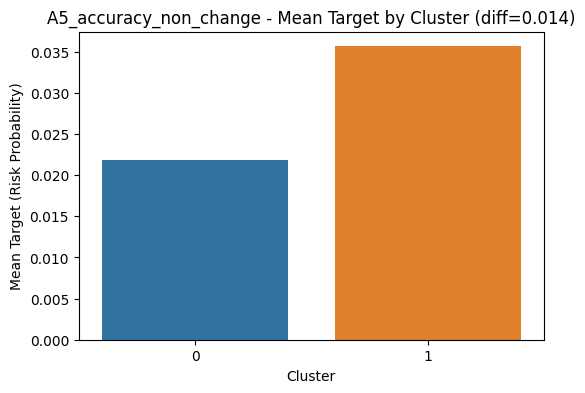

Feature: A5_accuracy_pos_change, Silhouette Score: 0.9383
Cluster별 Target 평균:
Cluster
0    0.021972
1    0.040302
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0183


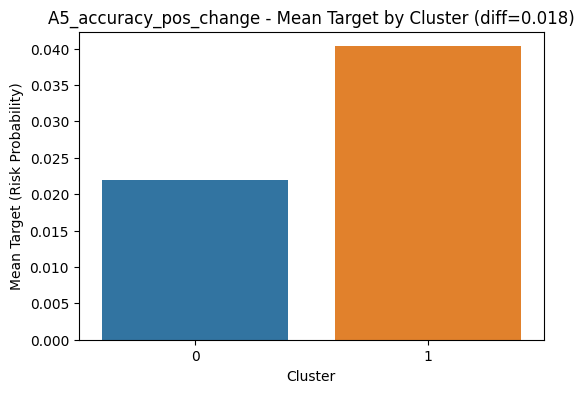

Feature: A5_accuracy_color_change, Silhouette Score: 0.6321
Cluster별 Target 평균:
Cluster
1    0.019968
0    0.027273
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0073


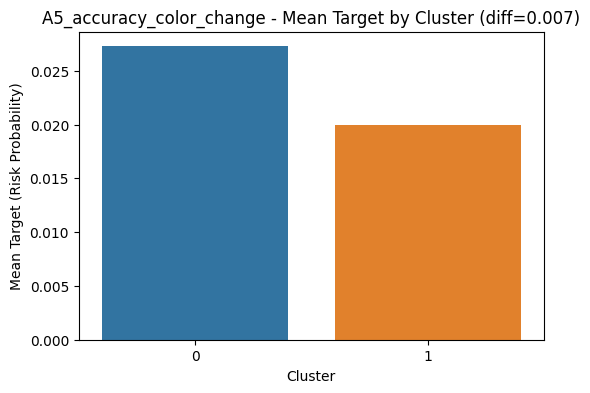

Feature: A5_accuracy_shape_change, Silhouette Score: 0.6525
Cluster별 Target 평균:
Cluster
1    0.020056
0    0.024986
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0049


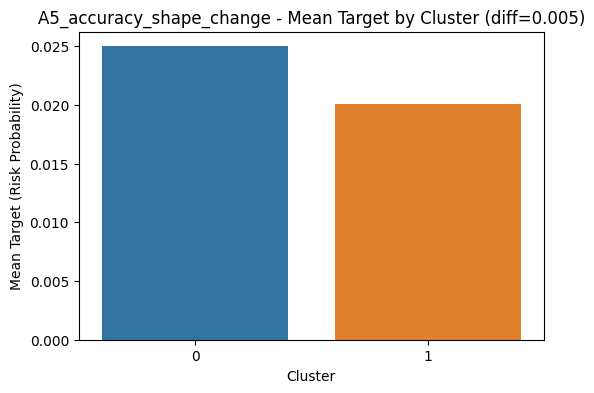

Feature: A5_accuracy_var, Silhouette Score: 0.6474
Cluster별 Target 평균:
Cluster
0    0.020901
1    0.027168
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0063


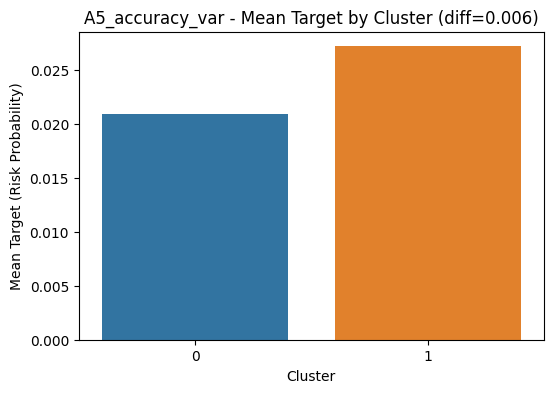

In [27]:
feature_list = ['A5_accuracy_non_change', 'A5_accuracy_pos_change',
                'A5_accuracy_color_change', 'A5_accuracy_shape_change',
                'A5_accuracy_var']
results_a5 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_a, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_a5.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [39]:
results_a5_df = pd.DataFrame(results_a5).sort_values('Cluster Diff', ascending=False)
results_a5_df

,Feature,Silhouette,Cluster Diff
1,A5_accuracy_pos_change,0.938320,0.018330
0,A5_accuracy_non_change,0.800992,0.013808
2,A5_accuracy_color_change,0.632128,0.007305
4,A5_accuracy_var,0.647366,0.006268
3,A5_accuracy_shape_change,0.652483,0.004930


## **A6, A7**

Feature: A6_score, Silhouette Score: 0.6385
Cluster별 Target 평균:
Cluster
1    0.019274
0    0.030910
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0116


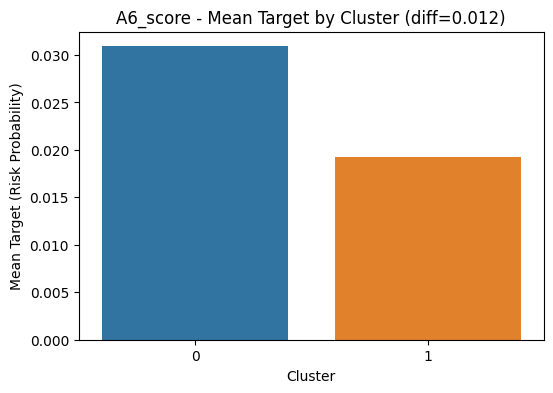

Feature: A6_zscore, Silhouette Score: 0.6385
Cluster별 Target 평균:
Cluster
1    0.019274
0    0.030910
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0116


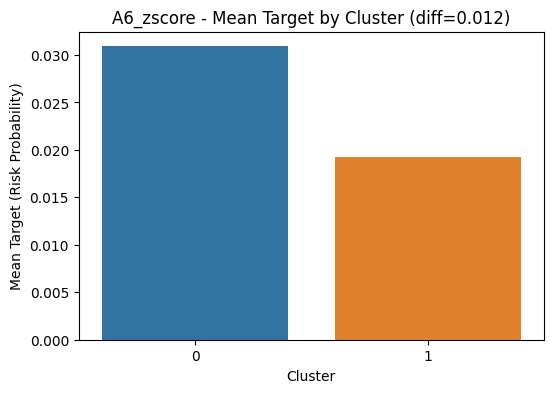

Feature: A7_score, Silhouette Score: 0.6061
Cluster별 Target 평균:
Cluster
1    0.016105
0    0.030258
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0142


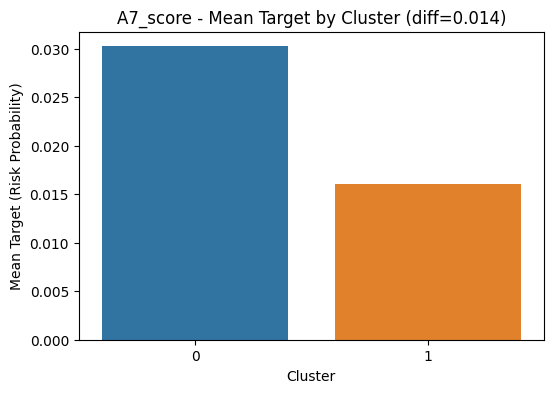

Feature: A7_zscore, Silhouette Score: 0.6061
Cluster별 Target 평균:
Cluster
1    0.016105
0    0.030258
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0142


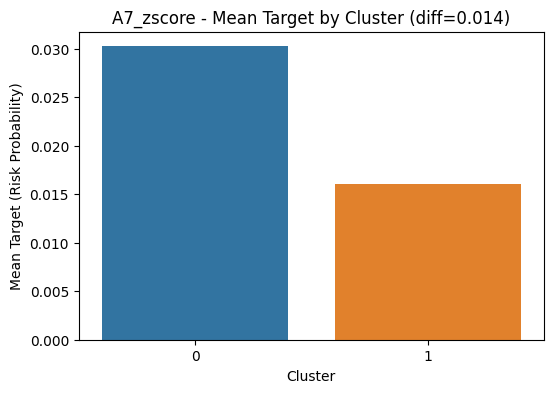

In [29]:
feature_list = ['A6_score', 'A6_zscore',
                'A7_score', 'A7_zscore']
results_a67 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_a, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_a67.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [40]:
results_a67_df = pd.DataFrame(results_a67).sort_values('Cluster Diff', ascending=False)
results_a67_df

,Feature,Silhouette,Cluster Diff
3,A7_zscore,0.606090,0.014153
2,A7_score,0.606090,0.014153
1,A6_zscore,0.638515,0.011636
0,A6_score,0.638515,0.011636


## **A8**

Feature: A8_distortion_score, Silhouette Score: 0.6451
Cluster별 Target 평균:
Cluster
0    0.020771
1    0.024914
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0041


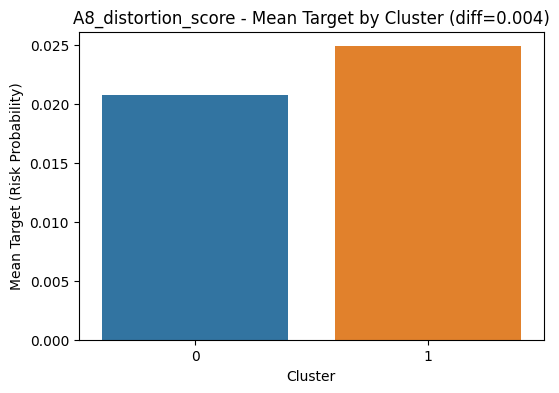

Feature: A8_consistency_score, Silhouette Score: 0.7198
Cluster별 Target 평균:
Cluster
1    0.019245
0    0.030245
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0110


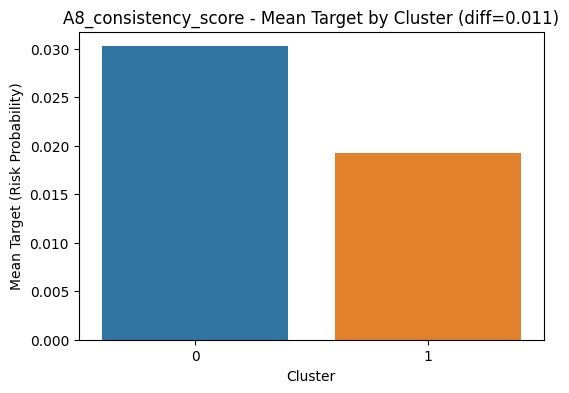

Feature: A8_distortion_flag, Silhouette Score: 1.0000
Cluster별 Target 평균:
Cluster
0    0.020771
1    0.024914
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0041


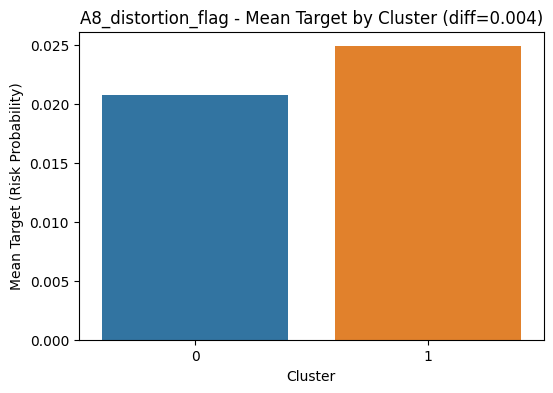

In [31]:
feature_list = ['A8_distortion_score', 'A8_consistency_score', 'A8_distortion_flag']
results_a8 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_a, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_a8.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [41]:
results_a8_df = pd.DataFrame(results_a8).sort_values('Cluster Diff', ascending=False)
results_a8_df

,Feature,Silhouette,Cluster Diff
1,A8_consistency_score,0.719828,0.011000
0,A8_distortion_score,0.645078,0.004143
2,A8_distortion_flag,1.000000,0.004143


## **A9**

Feature: A9_emotional_stability, Silhouette Score: 0.6349
Cluster별 Target 평균:
Cluster
1    0.021098
0    0.028612
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0075


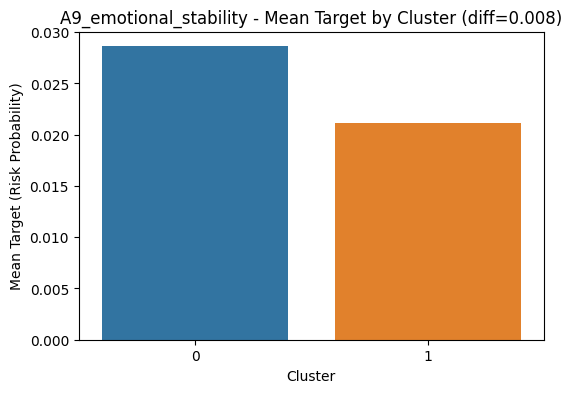

Feature: A9_behavior_stability, Silhouette Score: 0.5637
Cluster별 Target 평균:
Cluster
1    0.020909
0    0.025160
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0043


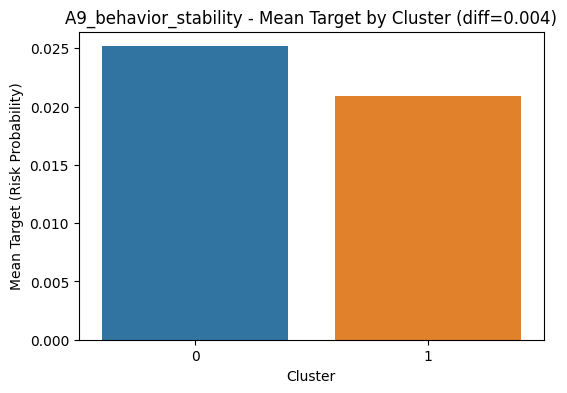

Feature: A9_reality_checking, Silhouette Score: 0.7623
Cluster별 Target 평균:
Cluster
0    0.021376
1    0.035015
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0136


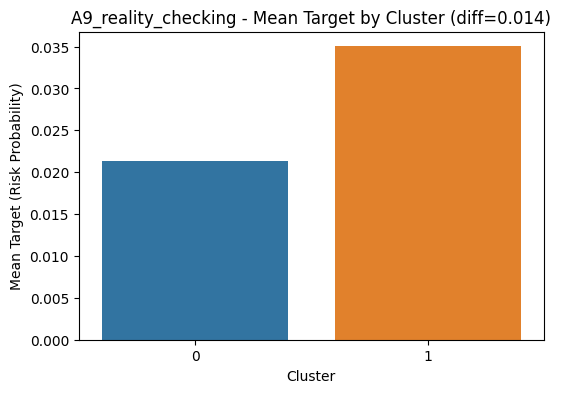

Feature: A9_cognitive_agility, Silhouette Score: 0.5939
Cluster별 Target 평균:
Cluster
0    0.021470
1    0.023246
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0018


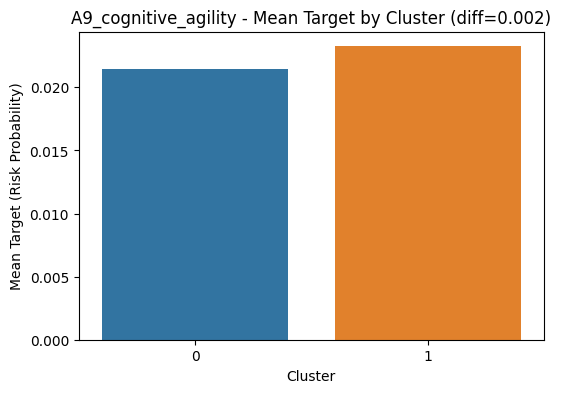

Feature: A9_stress_level, Silhouette Score: 0.6308
Cluster별 Target 평균:
Cluster
0    0.020532
1    0.028436
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0079


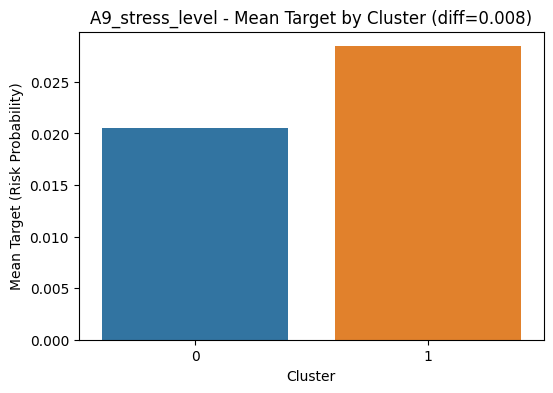

Feature: A9_total_score, Silhouette Score: 0.5849
Cluster별 Target 평균:
Cluster
1    0.020809
0    0.026948
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0061


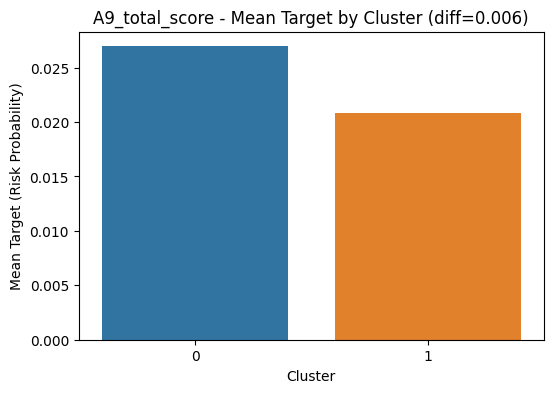

Feature: A9_stability_gap, Silhouette Score: 0.5231
Cluster별 Target 평균:
Cluster
1    0.022552
0    0.023025
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0005


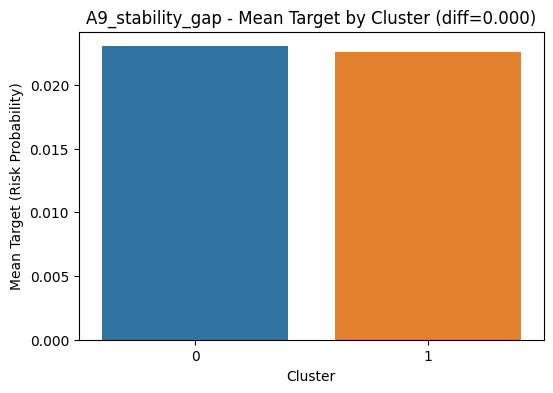

In [33]:
feature_list = ['A9_emotional_stability', 'A9_behavior_stability',
                'A9_reality_checking', 'A9_cognitive_agility',
                'A9_stress_level', 'A9_total_score', 'A9_stability_gap']
results_a9 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_a, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_a9.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [42]:
results_a9_df = pd.DataFrame(results_a9).sort_values('Cluster Diff', ascending=False)
results_a9_df

,Feature,Silhouette,Cluster Diff
2,A9_reality_checking,0.762257,0.013640
4,A9_stress_level,0.630779,0.007904
0,A9_emotional_stability,0.634890,0.007514
5,A9_total_score,0.584919,0.006139
1,A9_behavior_stability,0.563661,0.004251
3,A9_cognitive_agility,0.593934,0.001775
6,A9_stability_gap,0.523145,0.000473


# **Result**

In [43]:
results_df = pd.DataFrame(results).sort_values('Cluster Diff', ascending=False)
results_df.head(20)

,Feature,Silhouette,Cluster Diff
2,A1_left_response_rate,0.966562,0.022983
3,A1_right_response_rate,0.963386,0.022980
1,A1_response_rate,0.964039,0.022934
17,A3_correct_rt,0.998061,0.019557
0,Age,0.668332,0.019095
28,A5_accuracy_pos_change,0.938320,0.018330
5,A1_mean_response_time,0.979427,0.017519
4,A1_fast_response_rate,0.960357,0.017459
7,A1_direction_diff_rt,0.996880,0.016554
9,A2_slow_to_fast_rt_diff,0.991868,0.015803
